# 04_05 Classification - GBTClassifier with CrossValidator

Train and evaluate GBTClassifier using k-fold CrossValidator (3-fold) for hyperparameter tuning.

**Note:** This notebook uses CrossValidator (k-fold CV) instead of TrainValidationSplit, satisfying UTIL-04 requirement.
**Important:** GBTClassifier is the slowest model, so we only tune 1 parameter (maxIter). Runs sequentially (parallelism=1).

## [COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train GBTClassifier voi CrossValidator (3-fold).
- Muc tieu ky thuat: Grid nho (chi 1 param), chay tuan tu, so sanh CV vs TVS.

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import time

# Spark session setup
spark = (SparkSession.builder
    .appName('04_05_gbt_cv') # type: ignore
    .master('local[2]')
    .config('spark.sql.shuffle.partitions','16')
    .getOrCreate())
spark.sparkContext.setLogLevel('WARN')

# Paths
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
MODEL_DIR = PROJECT_ROOT / 'models' / 'classification' / 'gbt_classifier_cv_best'
METRIC_DIR = PROJECT_ROOT / 'reports' / 'model_metrics'
CROSSVAL_DIR = METRIC_DIR / 'crossvalidator'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
CROSSVAL_DIR.mkdir(parents=True, exist_ok=True)

# Load data
train_df = spark.read.parquet(str(FEATURE_DIR / 'classification_train')).select('order_id','label','features').dropna()
val_df = spark.read.parquet(str(FEATURE_DIR / 'classification_val')).select('order_id','label','features').dropna()
test_df = spark.read.parquet(str(FEATURE_DIR / 'classification_test')).select('order_id','label','features').dropna()

print(f"Train rows: {train_df.count()}, Val rows: {val_df.count()}, Test rows: {test_df.count()}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/03 00:03:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/03 00:03:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/03 00:03:49 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/03 00:03:49 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/04/03 00:03:49 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


Train rows: 68887, Val rows: 14546, Test rows: 14734


## Setup CrossValidator with Minimal ParamGrid

**CrossValidator Configuration:**
- numFolds=3 (k-fold cross-validation)
- Grid: maxIter=[10, 20, 30] (ONLY 1 param - GBT is slowest)
- Metric: Accuracy (for CV optimization)
- parallelism=1 (GBT MUST run sequentially to avoid OOM)

In [2]:
# Define model
gbt = GBTClassifier(featuresCol='features', labelCol='label', seed=42, maxDepth=5, stepSize=0.1)

# Build MINIMAL param grid (1x3 = 3 combinations only)
# GBT is slowest model - only tune 1 param (maxIter)
param_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxIter, [10, 20, 30])  # ONLY maxIter - per locked decision
    .build()
)

print(f"Total param combinations: {len(param_grid)} (minimal grid for GBT)")

# Evaluator for CV
cv_evaluator = MulticlassClassificationEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='accuracy'
)

# CrossValidator setup - NOTE: parallelism=1 is CRITICAL for GBT
cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=3,  # KEY: 3-fold cross-validation
    seed=42,
    parallelism=1  # CRITICAL: GBT MUST run sequentially to avoid OOM
)

print("CrossValidator configured:")
print(f"  - numFolds: 3")
print(f"  - parallelism: 1 (SEQUENTIAL - GBT is memory-intensive)")
print(f"  - param combinations: {len(param_grid)} (only maxIter)")
print(f"  - total models trained: {len(param_grid) * 3}")
print(f"  - maxDepth fixed at 5, stepSize fixed at 0.1")

Total param combinations: 3 (minimal grid for GBT)
CrossValidator configured:
  - numFolds: 3
  - parallelism: 1 (SEQUENTIAL - GBT is memory-intensive)
  - param combinations: 3 (only maxIter)
  - total models trained: 9
  - maxDepth fixed at 5, stepSize fixed at 0.1


## Run CrossValidator

This will train 9 models (3 param combos x 3 folds) sequentially.
⚠️ Warning: This may take longer due to sequential training and GBT complexity.

In [3]:
# Fit CrossValidator
start_time = time.time()
print("Training CrossValidator (3-fold) for GBTClassifier...")
print("⚠️ GBT is slow - sequential training with small grid")
print("⏳ Please wait...")

cv_model = cv.fit(train_df)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Get best model
best_model = cv_model.bestModel
best_maxIter = best_model.getMaxIter() # type: ignore

print(f"\nBest params found:")
print(f"  maxIter: {best_maxIter}")
print(f"  (maxDepth=5, stepSize=0.1 fixed)")

Training CrossValidator (3-fold) for GBTClassifier...
⚠️ GBT is slow - sequential training with small grid
⏳ Please wait...


26/04/03 00:03:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/03 00:03:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



Training completed in 19.70 seconds (0.33 minutes)

Best params found:
  maxIter: 10
  (maxDepth=5, stepSize=0.1 fixed)


## Display All Param Combinations with CV Scores

In [4]:
# Extract param combinations and their avg CV scores
param_combos = []
for i, params in enumerate(param_grid):
    max_iter = params[gbt.maxIter]
    avg_score = cv_model.avgMetrics[i]
    param_combos.append({
        'maxIter': max_iter,
        'cv_avg_accuracy': float(avg_score)
    })

cv_results_df = pd.DataFrame(param_combos)
cv_results_df = cv_results_df.sort_values('cv_avg_accuracy', ascending=False)

print("All parameter combinations with CV scores (sorted by accuracy):")
display(cv_results_df)

# Save detailed CV results
cv_results_df.to_csv(CROSSVAL_DIR / 'cv_gbt_classifier.csv', index=False)
print(f"\nSaved to: {CROSSVAL_DIR / 'cv_gbt_classifier.csv'}")

All parameter combinations with CV scores (sorted by accuracy):


,maxIter,cv_avg_accuracy
0,10,0.77148
1,20,0.77148
2,30,0.77148



Saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/crossvalidator/cv_gbt_classifier.csv


## Evaluate Best Model on Validation and Test Sets

In [5]:
# Evaluate best model
pred_val = best_model.transform(val_df)
pred_test = best_model.transform(test_df)

# Metrics
val_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_val)
val_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_val)
test_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_test)
test_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_test)

# CV average metric for best params
best_cv_avg = max(cv_model.avgMetrics)

metrics = {
    'model_family': 'classification',
    'model_name': 'GBTClassifier_CV',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'best_maxIter': int(best_maxIter),
    'best_maxDepth': 5,
    'best_stepSize': 0.1,
    'cv_avg_accuracy': float(best_cv_avg),
    'val_f1': float(val_f1),
    'val_accuracy': float(val_acc),
    'test_f1': float(test_f1),
    'test_accuracy': float(test_acc),
    'train_rows': train_df.count(),
    'val_rows': val_df.count(),
    'test_rows': test_df.count(),
    'training_time_seconds': float(training_time),
    'total_combinations': len(param_grid),
    'note': 'Small grid due to GBT computational cost'
}

print("\nFinal Metrics:")
print(metrics)
display(pd.DataFrame([metrics]))


Final Metrics:
{'model_family': 'classification', 'model_name': 'GBTClassifier_CV', 'tuning_method': 'CrossValidator', 'num_folds': 3, 'best_maxIter': 10, 'best_maxDepth': 5, 'best_stepSize': 0.1, 'cv_avg_accuracy': 0.7714802330648376, 'val_f1': 0.6674715852898907, 'val_accuracy': 0.7681836931115084, 'test_f1': 0.6786282662928452, 'test_accuracy': 0.7763675851771413, 'train_rows': 68887, 'val_rows': 14546, 'test_rows': 14734, 'training_time_seconds': 19.704508066177368, 'total_combinations': 3, 'note': 'Small grid due to GBT computational cost'}


,model_family,model_name,tuning_method,num_folds,best_maxIter,best_maxDepth,best_stepSize,cv_avg_accuracy,val_f1,val_accuracy,test_f1,test_accuracy,train_rows,val_rows,test_rows,training_time_seconds,total_combinations,note
0,classification,GBTClassifier_CV,CrossValidator,3,10,5,0.1,0.77148,0.667472,0.768184,0.678628,0.776368,68887,14546,14734,19.704508,3,Small grid due to GBT computational cost


## Confusion Matrix

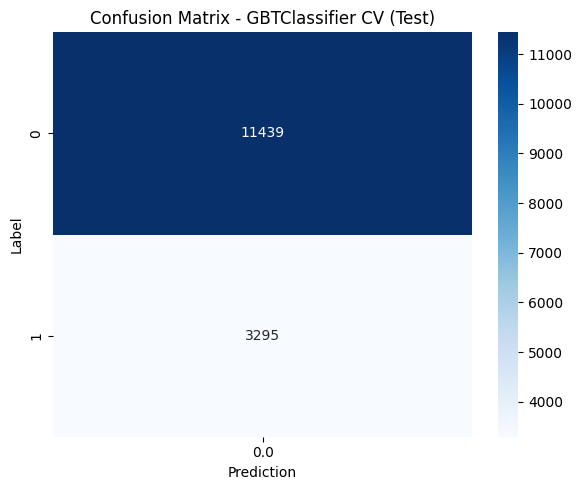

In [6]:
cm_pdf = pred_test.groupBy('label', 'prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table = cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - GBTClassifier CV (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()

## CrossValidator vs TrainValidationSplit Comparison

In [7]:
# Load TVS results from existing GBT notebook
tvs_path = METRIC_DIR / 'classification_gbt_classifier.json'
tvs_metrics = {}
if tvs_path.exists():
    with open(tvs_path) as f:
        tvs_data = json.load(f)
    tvs_metrics = {
        'tvs_val_accuracy': tvs_data.get('val_accuracy', 'N/A'),
        'tvs_test_accuracy': tvs_data.get('test_accuracy', 'N/A'),
        'tvs_test_f1': tvs_data.get('test_f1', 'N/A')
    }

# Create comparison
comparison = {
    'metric': ['CV Avg Accuracy', 'Test Accuracy', 'Test F1-Score', 'Training Time'],
    'CrossValidator_CV': [
        f"{best_cv_avg:.4f} (3 folds)",
        f"{test_acc:.4f}",
        f"{test_f1:.4f}",
        f"{training_time:.2f}s"
    ],
    'TrainValidationSplit': [
        'N/A (single split)',
        f"{tvs_metrics.get('tvs_test_accuracy', 'N/A')}",
        f"{tvs_metrics.get('tvs_test_f1', 'N/A')}",
        'faster (single split)'
    ]
}

comparison_df = pd.DataFrame(comparison)
print("CrossValidator vs TrainValidationSplit Comparison:")
display(comparison_df)

# Save comparison
comparison_df.to_csv(CROSSVAL_DIR / 'cv_vs_tvs_gbt_classifier.csv', index=False)

print(f"\nKey Trade-offs:")
print(f"- CV: More robust (3-fold), but {training_time:.2f}s with small grid")
print(f"- TVS: Faster, but single split is less stable")
print(f"- GBT limited to 3 maxIter values due to computational cost")

CrossValidator vs TrainValidationSplit Comparison:


,metric,CrossValidator_CV,TrainValidationSplit
0,CV Avg Accuracy,0.7715 (3 folds),N/A (single split)
1,Test Accuracy,0.7764,0.7763675851771413
2,Test F1-Score,0.6786,0.6786282662928452
3,Training Time,19.70s,faster (single split)



Key Trade-offs:
- CV: More robust (3-fold), but 19.70s with small grid
- TVS: Faster, but single split is less stable
- GBT limited to 3 maxIter values due to computational cost


## Save Model and Metrics

In [8]:
# Save best model
best_model.write().overwrite().save(str(MODEL_DIR))
print(f"Best model saved to: {MODEL_DIR}")

# Save metrics
metrics_path = METRIC_DIR / 'classification_gbt_classifier_cv.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to: {metrics_path}")

# Save tuning report
tuning_report = {
    'model_family': 'classification',
    'model_name': 'GBTClassifier',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'metric': 'accuracy',
    'avgMetrics': [float(x) for x in cv_model.avgMetrics],
    'bestParams': {
        'maxIter': int(best_maxIter),
        'maxDepth': 5,
        'stepSize': 0.1
    },
    'parallelism': 1,
    'note': 'GBT is slowest - only maxIter tuned, parallelism=1 required'
}

tuning_path = METRIC_DIR / 'tuning_classification_gbt_classifier_cv.json'
with open(tuning_path, 'w') as f:
    json.dump(tuning_report, f, indent=2)
print(f"Tuning report saved to: {tuning_path}")

print("\n✅ CrossValidator training complete!")
print(f"\nSummary:")
print(f"  - Best maxIter: {best_maxIter}")
print(f"  - CV avg accuracy: {best_cv_avg:.4f}")
print(f"  - Test accuracy: {test_acc:.4f}")
print(f"  - Training time: {training_time:.2f}s")

Best model saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/models/classification/gbt_classifier_cv_best
Metrics saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/classification_gbt_classifier_cv.json
Tuning report saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/tuning_classification_gbt_classifier_cv.json

✅ CrossValidator training complete!

Summary:
  - Best maxIter: 10
  - CV avg accuracy: 0.7715
  - Test accuracy: 0.7764
  - Training time: 19.70s
